In [1]:
## Imports
import os
os.environ["R_HOME"] = r"C:\Program Files\R\R-4.0.3"
os.environ["PATH"]   = r"C:\Program Files\R\R-4.0.3\bin\x64" + ";" + os.environ["PATH"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as colmap
import seaborn as sns
from set_tex_fonts import set_latex_font
from motor_control_tools.adapted_processing import *
import pingouin as pg
import motor_control_tools.figures as figures
import motor_control_tools.signal as signal
import manage_expe as me
import motor_control_tools as mct
import re
import pickle
from scipy.stats import pearsonr

****
Working on Transp_2DDL data
****


In [2]:
set_latex_font()

In [3]:
# Size of one plot and resolution
pltSizex = 10
pltSizey = 10
dpi = 300
# Fontsize for the different parameters
legFont = 55
xTitleFont = 60
yTitleFont = 60
xLabelFont = 55
yLabelFont = 55
# Define linewidth for line plots
lw = 5
# Color for each condition
cmap = colmap.get_cmap('nipy_spectral')
amp15_col = cmap(0.0)
amp30_col = cmap(0.9)
amp45_col  = cmap(0.15)
amp60_col  = cmap(0.5)
# Error bars
ci = "sd"

C:\Users\nairo\AppData\Local\Temp\ipykernel_5388\3421635822.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = colmap.get_cmap('nipy_spectral')


In [4]:
## Load population kinematics
all_qtm_data = pd.read_csv("./all_params/Transp_2DDL_index_cut-off-rel-5.csv", encoding = "ISO-8859-1", engine='python')
all_rob_data = pd.read_csv("./all_params/Transp_2DDL_rob_cut-off-rel-5.csv", encoding = "ISO-8859-1", engine='python')

## Extract best transparency data
all_qtm_data_TR = all_qtm_data[all_qtm_data['condition'] == 'OLCL']
all_rob_data_TR = all_rob_data[all_rob_data['condition'] == 'OLCL']

[245, 472]
11.51645852980594


IndexError: list index out of range

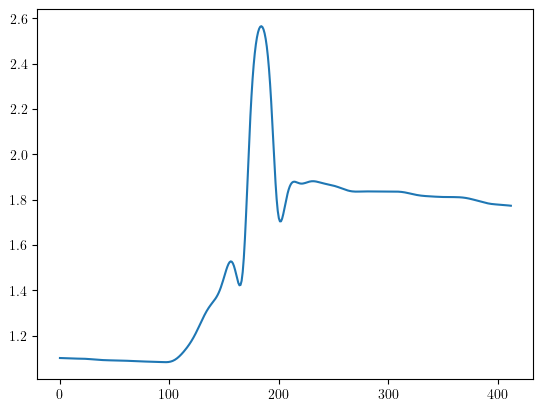

In [5]:
## Check relationship with a random movement
# Get file path
i = 1
humanfile = all_qtm_data_TR['file_name'].iloc[i]
robfile = all_rob_data_TR['file_name'].iloc[i]

# Extract movement dicts
with open(humanfile, 'rb') as hkin:
    dict_hkin = pickle.load(hkin)
with open(robfile, 'rb') as rkin:
    dict_rkin = pickle.load(rkin)

# Relative threshold
cut = 0.05

## Handle human joints segmentation
# Get human joints angles & vels
hdf_mov = dict_hkin.get('df_mov')
q_sh = hdf_mov['q_sh']
q_el = hdf_mov['q_el']
q_sh_dot = mct.signal.diff_keep_length(q_sh, 100, spec_t = False)
q_el_dot = mct.signal.diff_keep_length(q_el, 100, spec_t = False)
# Get human joints movement bounds
bounds_sh = cut_vel_submovements(q_sh_dot, cut = cut)
bounds_el = cut_vel_submovements(q_el_dot, cut = cut)
bounds_human = compare_bounds(bounds_sh, bounds_el)
# Get bounded joints profiles
pv_sh = np.max(np.abs(q_sh_dot))
pv_el = np.max(np.abs(q_el_dot))

## Handle robot joints segmentation
# Get robot joints angles & vels
rdf_mov = dict_rkin.get('df_mov')
q_3 = rdf_mov['pos_A']
q_4 = rdf_mov['pos_FA'] + np.pi/2
q_3_dot = mct.signal.diff_keep_length(q_3, 100, spec_t = False)
q_4_dot = mct.signal.diff_keep_length(q_4, 100, spec_t = False)
# Get robot joints movement bounds
bounds_q_3 = cut_vel_submovements(q_3_dot, cut = cut, rob = True, pv_h = pv_sh)
print(bounds_q_3)
bounds_q_4 = cut_vel_submovements(q_4_dot, cut = cut, rob = True, pv_h = pv_el)
print(pv_el)
plt.plot(q_el)
bounds_robot = compare_bounds(bounds_q_3, bounds_q_4)

## Get common bounds
bounds_human, bounds_robot = compare_bounds(bounds_human, bounds_robot, both = True)
## Get bounded joints profiles
# Human
q_sh_b = q_sh[bounds_human[0]:bounds_human[1]]
q_el_b = q_el[bounds_human[0]:bounds_human[1]]
q_sh_dot_b = q_sh_dot[bounds_human[0]:bounds_human[1]]
q_el_dot_b = q_el_dot[bounds_human[0]:bounds_human[1]]
# Robot
q_3_b = q_3[bounds_robot[0]:bounds_robot[1]]
q_4_b = q_4[bounds_robot[0]:bounds_robot[1]]
q_3_dot_b = q_3_dot[bounds_robot[0]:bounds_robot[1]]
q_4_dot_b = q_4_dot[bounds_robot[0]:bounds_robot[1]]
# Extend profiles at each joint
q_sh_be, q_sh_dot_be, q_3_be, q_3_dot_be = extend_bounded_profiles(q_sh_b, q_sh_dot_b, q_3_b, q_3_dot_b)
q_el_be, q_el_dot_be, q_4_be, q_4_dot_be = extend_bounded_profiles(q_el_b, q_el_dot_b, q_4_b, q_4_dot_b)

print(np.shape(np.concat((q_el_be.reshape(len(q_el_be),1), q_sh_dot_be.reshape(len(q_el_be),1)), axis = 1)))

# Time vectors
t_h = np.linspace(0, len(q_sh_be)*0.01, len(q_sh_be))
t_r = np.linspace(0, len(q_3_be)*0.01, len(q_3_be))

fig, axes = plt.subplots(2,2,figsize = (0.4 * pltSizex, 0.4 * pltSizey), dpi = dpi)

axes[0,0].plot(t_h, q_sh_be)
axes[0,0].plot(t_r, q_3_be)

axes[0,1].plot(t_h, q_el_be)
axes[0,1].plot(t_r, q_4_be)

axes[1,0].plot(t_h, q_sh_dot_be)
axes[1,0].plot(t_r, q_3_dot_be)

axes[1,1].plot(t_h, q_el_dot_be)
axes[1,1].plot(t_r, q_4_dot_be)

In [6]:
df_one_subj_h = all_qtm_data_TR[all_qtm_data_TR['subject'] == 'S1']
df_one_subj_r = all_rob_data_TR[all_rob_data_TR['subject'] == 'S1']

test_mat = get_all_aligned_hr_joints_mvts_one_subj(df_one_subj_h, df_one_subj_r, cut = 0.05)
np.shape(test_mat)

(25189, 12)